# RPS Predictor — Good vs Bad Sample Analysis

Compares representative good predictions against catastrophically bad ones
to understand the failure modes visually.

In [7]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import torchaudio
import torch

INFERENCE_DIR = "../results/rps_predictor_comparison/val_inference"
DATA_DIR      = "../datasets/DREGON-LM/valid"
N_FFT, HOP    = 2048, 512
SR            = 16000
BAD_THRESH    = -5.0

In [8]:
with open(os.path.join(INFERENCE_DIR, "per_sample_metrics.json")) as f:
    all_metrics = json.load(f)

all_r2 = sorted(
    [s for s in all_metrics if s["r2"] is not None],
    key=lambda s: s["r2"]
)

bad  = [s for s in all_r2 if s["r2"] <  BAD_THRESH]
good = [s for s in all_r2 if s["r2"] >= BAD_THRESH]

r2_bad  = np.array([s["r2"] for s in bad])
r2_good = np.array([s["r2"] for s in good])

print(f"Total valid: {len(all_r2)}   Bad (R²<{BAD_THRESH}): {len(bad)}   Good: {len(good)}")
print()
print(f"R² all valid:  mean={np.array([s['r2'] for s in all_r2]).mean():.4f}  "
      f"median={np.median([s['r2'] for s in all_r2]):.4f}")
print(f"R² excl. bad:  mean={r2_good.mean():.4f}  median={np.median(r2_good):.4f}  "
      f"std={r2_good.std():.4f}")
print()
print("Bad samples:")
for s in bad:
    print(f"  {s['sample']}  R²={s['r2']:>10.3f}  MAE/clip={s['mae_clip']:.3f}  ss_tot={s['ss_tot']:.4f}")

Total valid: 597   Bad (R²<-5.0): 6   Good: 591

R² all valid:  mean=-7.6121  median=0.7817
R² excl. bad:  mean=0.6554  median=0.7833  std=0.4599

Bad samples:
  sample_00305  R²= -1994.305  MAE/clip=0.725  ss_tot=0.4731
  sample_00548  R²= -1824.346  MAE/clip=0.401  ss_tot=0.2080
  sample_00496  R²= -1072.414  MAE/clip=0.124  ss_tot=0.4295
  sample_00372  R²=   -25.052  MAE/clip=1.767  ss_tot=96.6370
  sample_00304  R²=    -9.222  MAE/clip=4.446  ss_tot=740.9005
  sample_00057  R²=    -6.434  MAE/clip=4.430  ss_tot=847.5754


In [9]:
def load_sample(sample_name):
    """Load predicted RPS, ground-truth RPS, and audio waveform for one sample."""
    inf_dir = os.path.join(INFERENCE_DIR, sample_name)
    pred = np.load(os.path.join(inf_dir, "predicted_rps.npy"))   # (4, T)
    gt   = np.load(os.path.join(inf_dir, "ground_truth_rps.npy"))  # (4, T)
    wav_path = os.path.join(DATA_DIR, sample_name, "mixture.wav")
    wav = None
    if os.path.exists(wav_path):
        wav, _ = torchaudio.load(wav_path)
        wav = wav[0].numpy()
    return pred, gt, wav


def compute_spectrogram(wav):
    X = torch.stft(
        torch.tensor(wav), n_fft=N_FFT, hop_length=HOP,
        window=torch.hann_window(N_FFT), return_complex=True, normalized=True,
    )
    return 20 * np.log10(X.abs().numpy() + 1e-8)  # (F, T)


def plot_sample(ax_spec, ax_rps, sample_name, r2, mae_clip, ss_tot, wav):
    """Fill one row: spectrogram on the left, RPS comparison on the right."""
    pred, gt, wav_loaded = load_sample(sample_name)
    if wav is None:
        wav = wav_loaded

    T = gt.shape[1]
    t = np.arange(T) * HOP / SR
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    # Spectrogram
    if wav is not None:
        spec = compute_spectrogram(wav)
        duration = len(wav) / SR
        ax_spec.imshow(
            spec, origin='lower', aspect='auto',
            extent=[0, duration, 0, SR / 2 / 1000],
            vmin=-80, vmax=0, cmap='magma',
        )
        ax_spec.set_ylabel('Freq (kHz)')
    else:
        ax_spec.text(0.5, 0.5, 'audio not synced', ha='center', va='center',
                     transform=ax_spec.transAxes, color='gray')
    ax_spec.set_title(
        f'{sample_name}   R²={r2:.3f}   MAE/clip={mae_clip:.3f}   ss_tot={ss_tot:.3f}',
        fontsize=9,
    )
    ax_spec.set_xlabel('Time (s)')

    # RPS
    for rotor in range(4):
        ax_rps.plot(t, gt[rotor],   color=colors[rotor], linewidth=1.2)
        ax_rps.plot(t, pred[rotor], color=colors[rotor], linewidth=1.0,
                    linestyle='--', alpha=0.75)
    # Proxy legend (solid = GT, dashed = pred)
    ax_rps.plot([], [], color='gray', linewidth=1.2, label='Ground truth')
    ax_rps.plot([], [], color='gray', linewidth=1.0, linestyle='--', alpha=0.75, label='Predicted')
    ax_rps.legend(fontsize=8, loc='upper right')
    ax_rps.set_xlabel('Time (s)')
    ax_rps.set_ylabel('RPS')

## Good predictions

6 representative samples spanning the R² range of the good set: top-3 best + 3 from the middle.

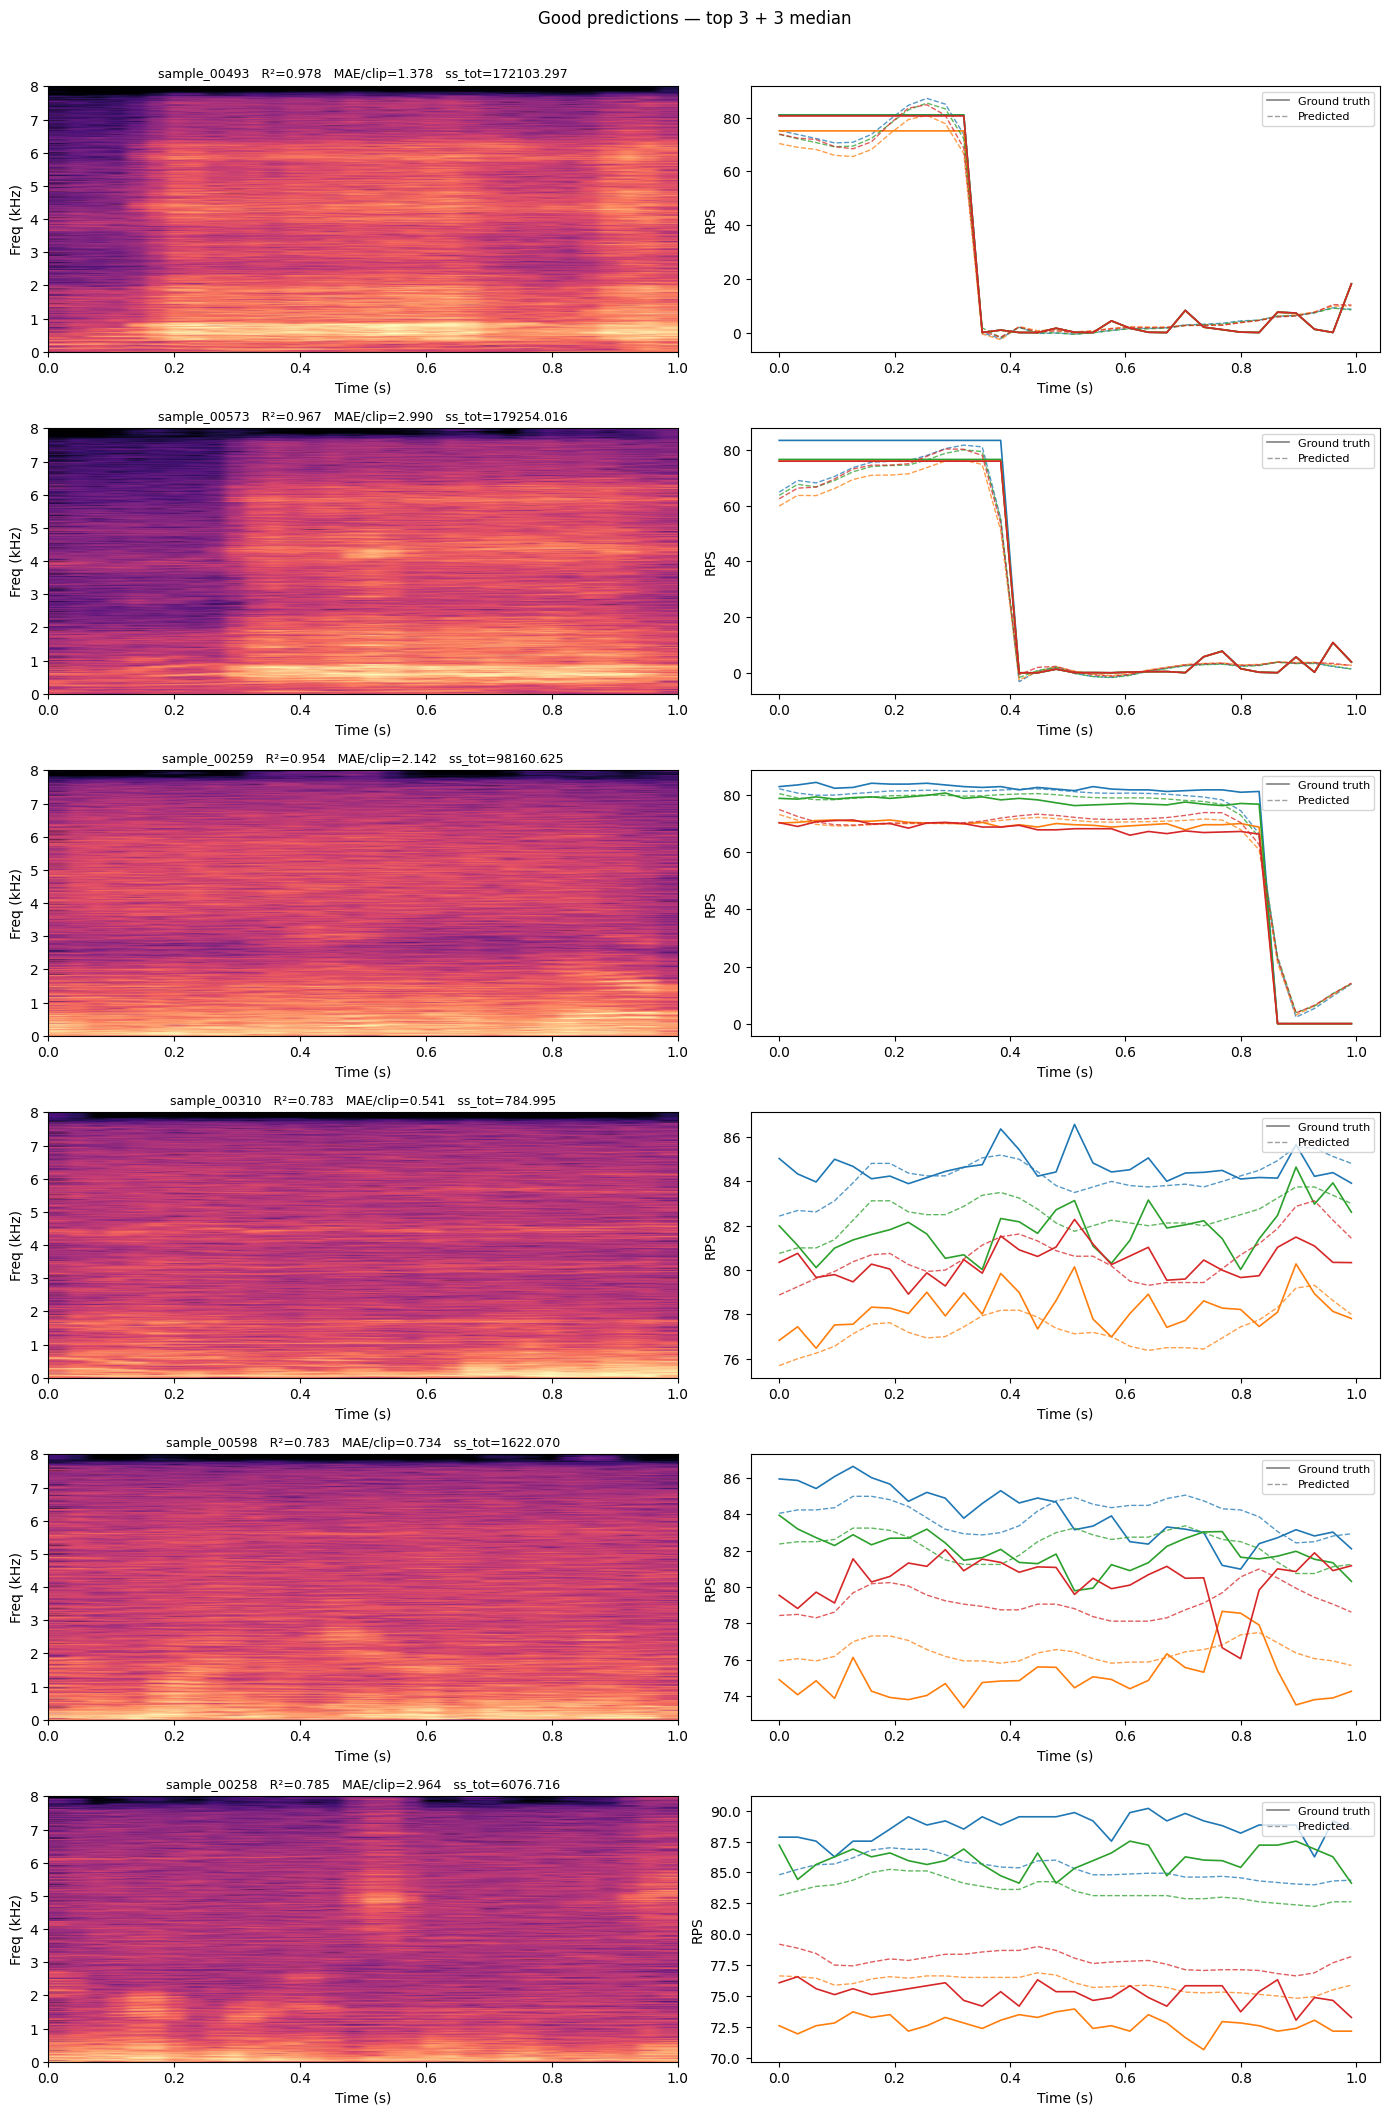

In [10]:
# Top 3 best + 3 from the middle of the good set
mid = len(good) // 2
showcase_good = good[-3:][::-1] + good[mid-1:mid+2]   # best-3 first, then mid-3

n = len(showcase_good)
fig, axes = plt.subplots(n, 2, figsize=(14, 3.5 * n))

for i, s in enumerate(showcase_good):
    plot_sample(axes[i][0], axes[i][1],
                s['sample'], s['r2'], s['mae_clip'], s['ss_tot'], wav=None)

plt.suptitle('Good predictions — top 3 + 3 median', fontsize=12, y=1.005)
plt.tight_layout()
plt.show()

## Bad predictions (R² < −5)

Split into two groups based on what's actually failing.

In [5]:
# Group 1: near-degenerate (tiny ss_tot, small absolute error, artefactual R²)
# Group 2: genuine failures (large ss_tot, large absolute error)
SS_TOT_DEGENERATE = 10.0
bad_degenerate = [s for s in bad if s['ss_tot'] < SS_TOT_DEGENERATE]
bad_genuine    = [s for s in bad if s['ss_tot'] >= SS_TOT_DEGENERATE]

print(f"Near-degenerate (ss_tot < {SS_TOT_DEGENERATE}): {len(bad_degenerate)} samples")
for s in bad_degenerate:
    print(f"  {s['sample']}  R²={s['r2']:>10.2f}  MAE/clip={s['mae_clip']:.3f}  ss_tot={s['ss_tot']:.4f}")
print()
print(f"Genuine failures (ss_tot ≥ {SS_TOT_DEGENERATE}): {len(bad_genuine)} samples")
for s in bad_genuine:
    print(f"  {s['sample']}  R²={s['r2']:>10.2f}  MAE/clip={s['mae_clip']:.3f}  ss_tot={s['ss_tot']:.2f}")

Near-degenerate (ss_tot < 10.0): 3 samples
  sample_00305  R²=  -1994.31  MAE/clip=0.725  ss_tot=0.4731
  sample_00548  R²=  -1824.35  MAE/clip=0.401  ss_tot=0.2080
  sample_00496  R²=  -1072.41  MAE/clip=0.124  ss_tot=0.4295

Genuine failures (ss_tot ≥ 10.0): 3 samples
  sample_00372  R²=    -25.05  MAE/clip=1.767  ss_tot=96.64
  sample_00304  R²=     -9.22  MAE/clip=4.446  ss_tot=740.90
  sample_00057  R²=     -6.43  MAE/clip=4.430  ss_tot=847.58


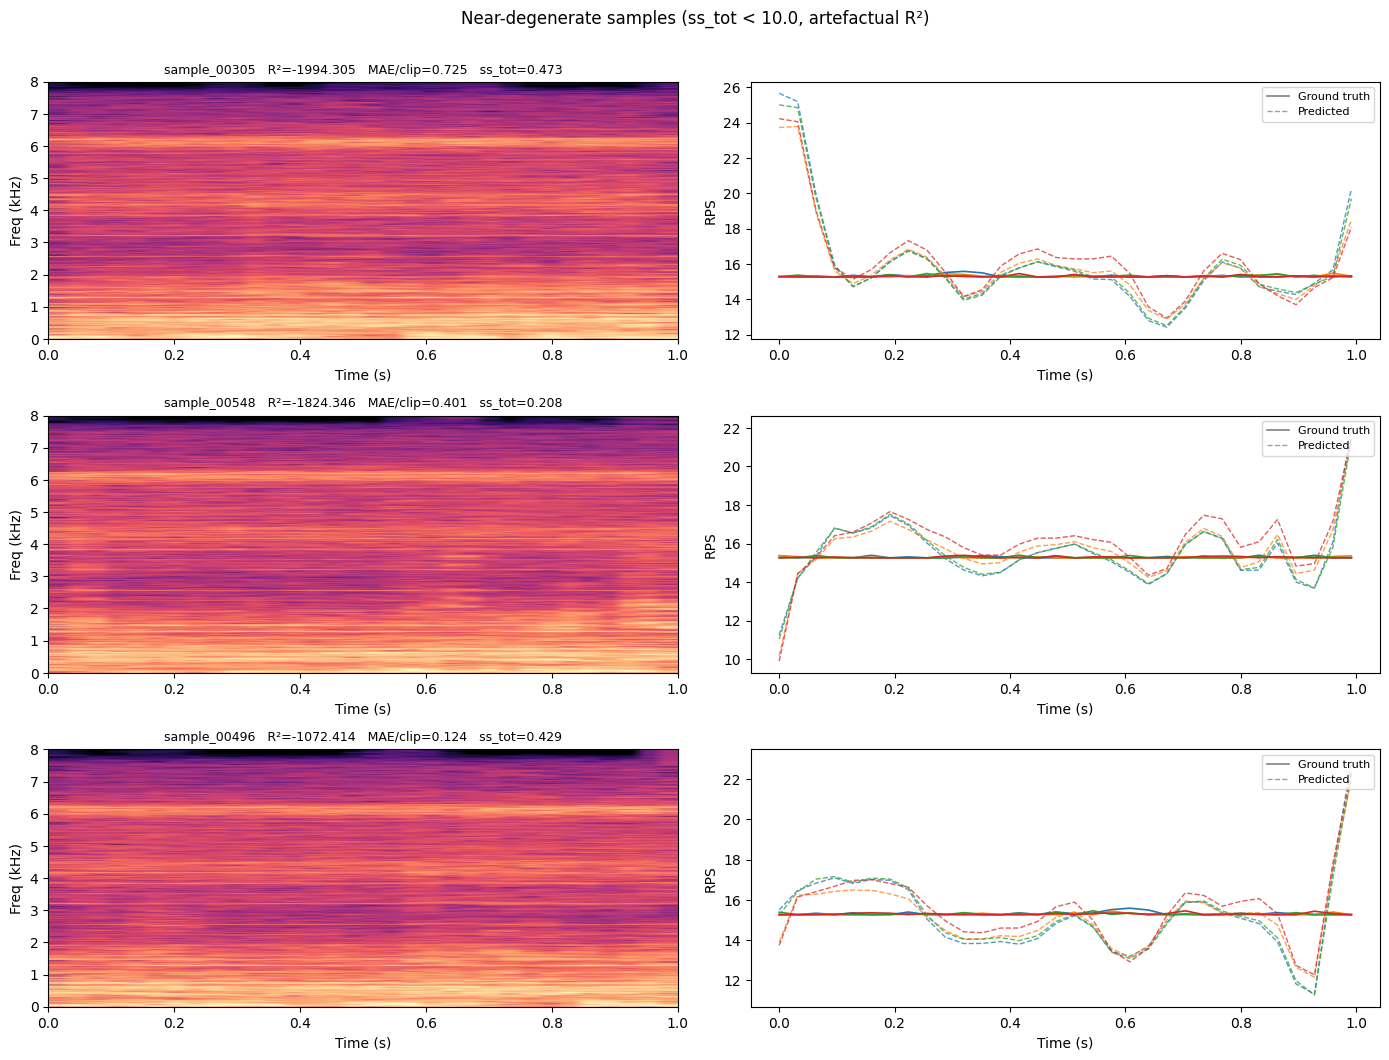

In [6]:
n = len(bad_degenerate)
fig, axes = plt.subplots(n, 2, figsize=(14, 3.5 * n))
if n == 1: axes = [axes]

for i, s in enumerate(bad_degenerate):
    plot_sample(axes[i][0], axes[i][1],
                s['sample'], s['r2'], s['mae_clip'], s['ss_tot'], wav=None)

plt.suptitle(f'Near-degenerate samples (ss_tot < {SS_TOT_DEGENERATE}, artefactual R²)',
             fontsize=12, y=1.005)
plt.tight_layout()
plt.show()

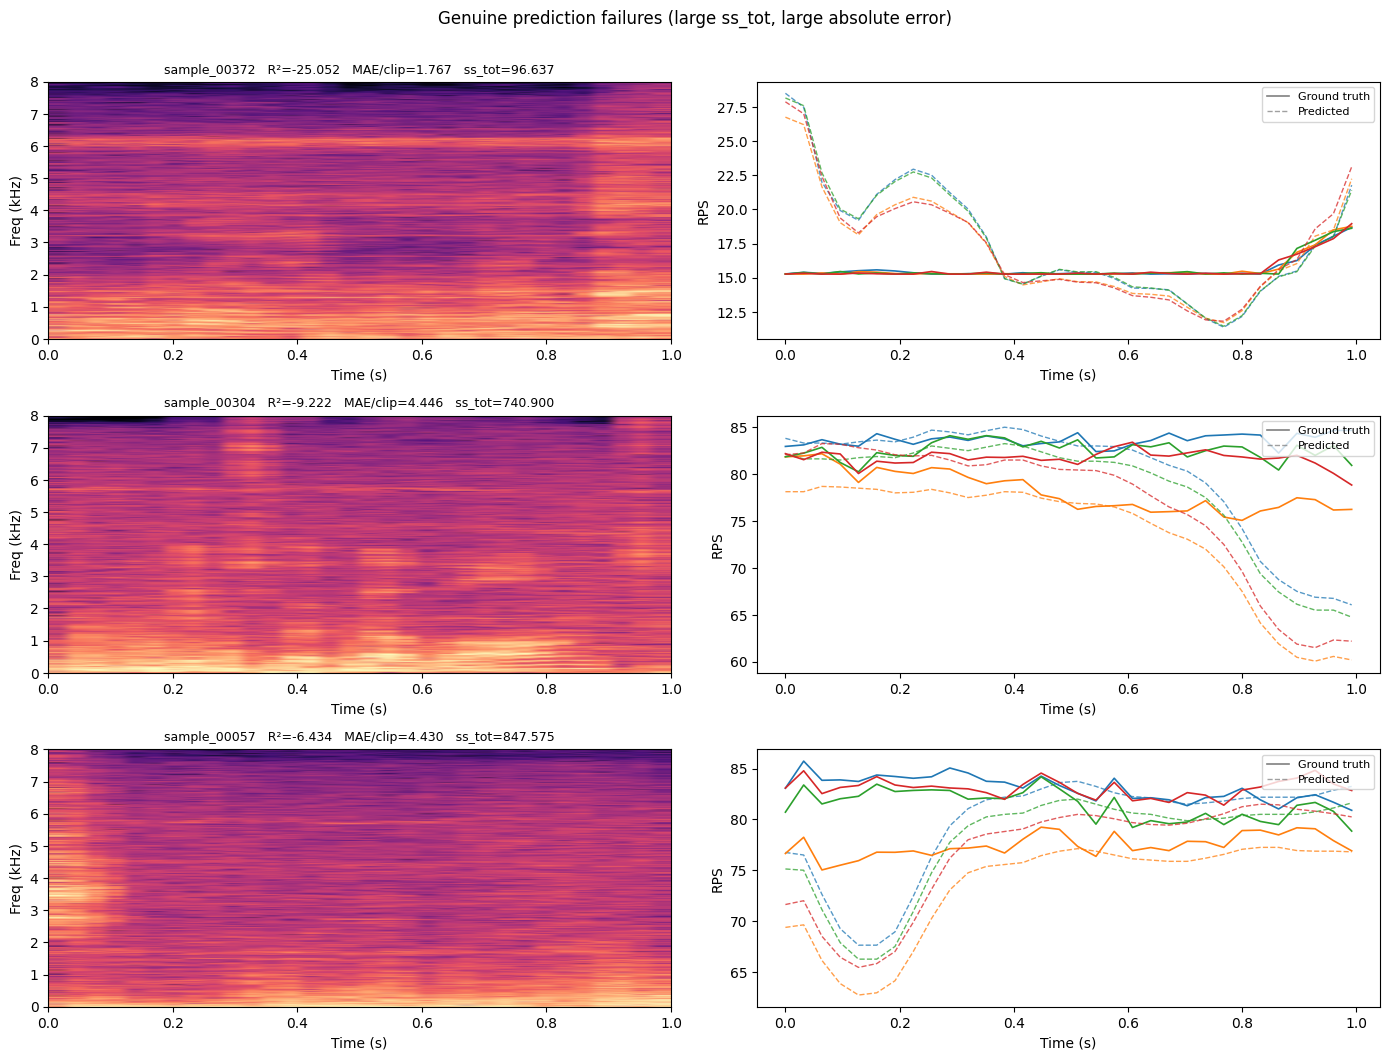

In [7]:
n = len(bad_genuine)
fig, axes = plt.subplots(n, 2, figsize=(14, 3.5 * n))
if n == 1: axes = [axes]

for i, s in enumerate(bad_genuine):
    plot_sample(axes[i][0], axes[i][1],
                s['sample'], s['r2'], s['mae_clip'], s['ss_tot'], wav=None)

plt.suptitle('Genuine prediction failures (large ss_tot, large absolute error)',
             fontsize=12, y=1.005)
plt.tight_layout()
plt.show()

## R² distribution and corrected summary

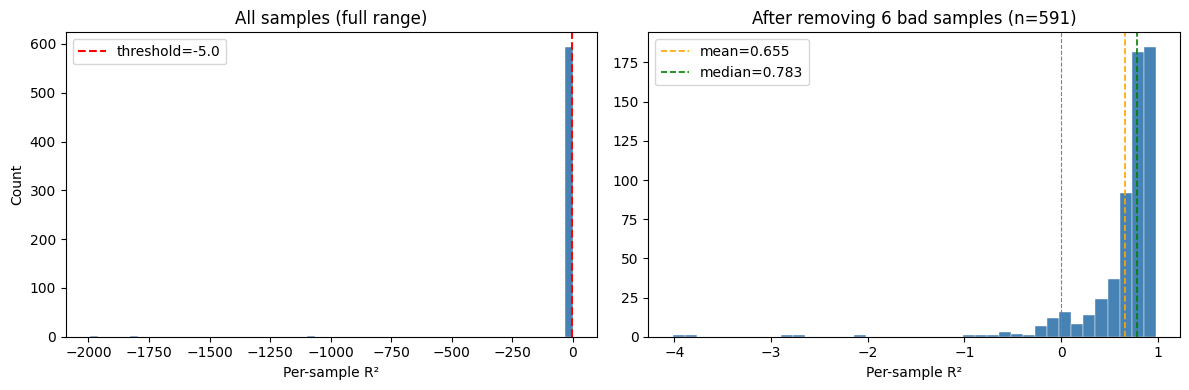


Final summary (n=591, excl. 6 outliers):
  RMSE      = 3.801 RPS
  MAE/clip  = 1.200 RPS
  R² mean   = 0.6554
  R² median = 0.7833
  R² std    = 0.4599


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

r2_all = np.array([s['r2'] for s in all_r2])
axes[0].hist(r2_all, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(BAD_THRESH, color='red', linestyle='--', label=f'threshold={BAD_THRESH}')
axes[0].set_xlabel('Per-sample R²')
axes[0].set_ylabel('Count')
axes[0].set_title('All samples (full range)')
axes[0].legend()

axes[1].hist(r2_good, bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].axvline(r2_good.mean(), color='orange', linestyle='--', linewidth=1.2,
                label=f'mean={r2_good.mean():.3f}')
axes[1].axvline(np.median(r2_good), color='green', linestyle='--', linewidth=1.2,
                label=f'median={np.median(r2_good):.3f}')
axes[1].set_xlabel('Per-sample R²')
axes[1].set_title(f'After removing {len(bad)} bad samples (n={len(good)})')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nFinal summary (n={len(good)}, excl. {len(bad)} outliers):")
print(f"  RMSE      = 3.801 RPS")
print(f"  MAE/clip  = 1.200 RPS")
print(f"  R² mean   = {r2_good.mean():.4f}")
print(f"  R² median = {np.median(r2_good):.4f}")
print(f"  R² std    = {r2_good.std():.4f}")